In [77]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import random_unitary, Statevector
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [78]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# Quantum error correction

Quantum error correction is a set of techniques used to protect quantum information from noise and unwanted interactions with the environment. This is necessary because qubits are extremely fragile: small errors can appear during computation, storage, or measurement, and these errors can destroy the quantum state being processed.

Unlike classical bits, qubits can suffer from different types of errors. A classical bit can mainly flip from $0$ to $1$ or from $1$ to $0$, but a qubit can also suffer changes in its phase. For this reason, quantum error correction must be able to detect and correct both bit-flip and phase-flip errors.

A **bit-flip error** is analogous to a classical error. It changes the state of a qubit as:

$$
|0\rangle \rightarrow |1\rangle
$$

and:

$$
|1\rangle \rightarrow |0\rangle
$$

This type of error is represented by the Pauli-$X$ gate.

A **phase-flip error** does not change the computational value of the qubit, but changes the relative phase between basis states. It acts as:

$$
|0\rangle \rightarrow |0\rangle
$$

and:

$$
|1\rangle \rightarrow -|1\rangle
$$

This type of error is represented by the Pauli-$Z$ gate.

The main idea of quantum error correction is to encode one logical qubit into several physical qubits. This redundancy allows us to detect where an error has occurred without directly measuring and destroying the quantum information. We will first study simple codes that correct only bit-flip and phase-flip errors, and then move towards more general and complete error correction schemes.

When working with quantum correction codes, we will use the following notation:

$$
[[n,k,d]]
$$
where:
- $n$: number of used physical qubits.
- $k$: number of encoded logical qubits.
- $d$: distance of the code.

In quantum codes, the distance is the minimum number of qubits that need to be affected by an error for the error to become undetectable. Therefore, a code with distance $d$ can detect up to $d-1$ errors and correct up to $\left\lfloor \frac{d-1}{2} \right\rfloor$ errors.

# Bit-flip

We will design the circuit using 3 qubits: the first one containing the original state and two auxiliary qubits on the $|0\rangle$ state. We will need two different stages. First, an encoding circuit introduces redundancy into the qubit we want to protect. Then, an error correction circuit detects and corrects possible errors. Let's assume that que initial state is:

$$
|\alpha \rangle = \alpha_0 |0\rangle + |\alpha_1 |1\rangle
$$

The encoding circuit will consist on two CNOT operations controlled by the first qubit and targets on each of the auxiliary qubits. That way, we will perform the transformation:

$$
(\alpha_0 |0\rangle + |\alpha_1 |1\rangle )\otimes |0\rangle \otimes |0\rangle \rightarrow \alpha_0 |000\rangle + \alpha_1 |111\rangle
$$

The error correction circuit will consist on two CNOT operations controlled by the first qubit and targets on each of the auxiliary qubits and a Toffoli gate targeting the first qubit. That way, given a arbitrary input $|x \rangle |y \rangle |z \rangle$, the circuit will perform the transformation:

$$
|x \rangle |y \rangle |z \rangle \xrightarrow{\text{CNOT gates}} |x \rangle |y \oplus x \rangle |z \oplus x \rangle \xrightarrow{\text{Toffoli gate}} |x \oplus (y \oplus x)\cdot (z \oplus x) \rangle |y \oplus x \rangle |z \oplus x \rangle
$$

Let's begin by analizing the states of the auxiliary qubits: their final state will only be $|1\rangle$ if and only if their original state was different from the first qubit's state. Measuring these qubits help us detect whether a bit flip has occurred.

Now, let's analyze the first register by expanding its expression:

$$
x \oplus (y \oplus x)\cdot (z \oplus x) = x \oplus (yz \oplus xy \oplus xz \oplus x^2) = xy \oplus xz \oplus yz
$$

Since the expression is symmetric for $x$, $y$ and $z$, this gives four possible cases:

| Case | Input state pattern | Expression $xy \oplus xz \oplus yz$ | 
|---|---|---:|
| All qubits are $0$ | $\|000\rangle$ | $0$ |
| Only one qubit is $1$ | $\|100\rangle$, $\|010\rangle$, $\|001\rangle$ | $0$ | 
| Two qubits are $1$ | $\|110\rangle$, $\|101\rangle$, $\|011\rangle$ | $1$ | 
| All qubits are $1$ | $\|111\rangle$ | $1$ | 

This shows that the correction circuit restores the first qubit according to the majority value of the three-qubit encoded state. Therefore, if at most one bit-flip error occurs, the original logical state can be recovered.

Let's now implement and test this circuit.

In [79]:
def bit_flip_circuit(initial_state: QuantumCircuit, bit_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds a 3-qubit bit-flip error correction circuit for a 1-qubit initial state, applying X noise according to bit_flip_idx.
    """

    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    
    # Create registers
    state = QuantumRegister(1, "State")
    aux = QuantumRegister(2, "aux")
    qc = QuantumCircuit(state, aux)

    # Prepare the initial state
    qc.compose(initial_state, qubits=state, inplace=True)

    qc.barrier()

    # Encoding: |alpha>|00> -> alpha_0|000> + alpha_1|111>
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])

    qc.barrier()

    # Noise
    if len(bit_flip_idx) > 0:
        qc.z(bit_flip_idx)

    qc.barrier()

    # Error correction
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])
    qc.ccx(aux[0], aux[1], state[0])

    return qc


First qubit initial state:


<IPython.core.display.Latex object>

##############################
Case: No bit-flip noise
##############################
Final state:


<IPython.core.display.Latex object>

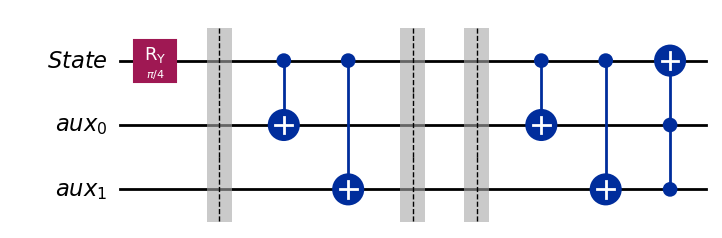

##############################
Case: Bit-flip noise on one qubit
##############################
Final state:


<IPython.core.display.Latex object>

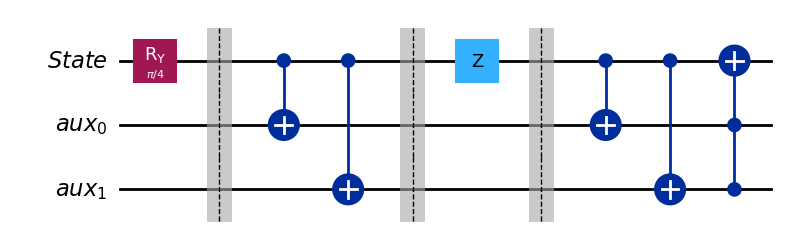

##############################
Case: Bit-flip noise on two qubits
##############################
Final state:


<IPython.core.display.Latex object>

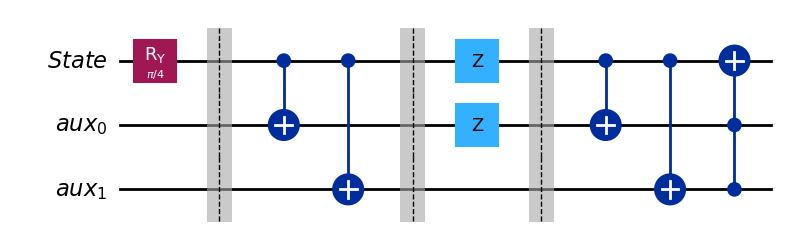

##############################
Case: Bit-flip noise on all three qubits
##############################
Final state:


<IPython.core.display.Latex object>

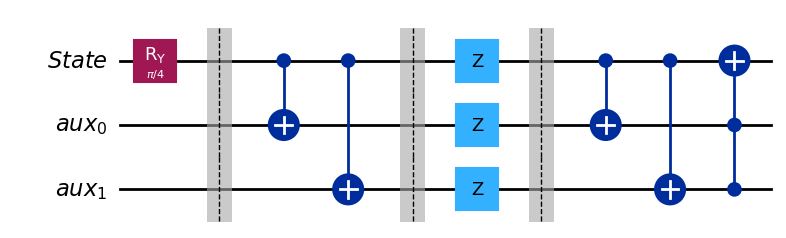

In [80]:
noise_cases = [
    [],  
    [0],   
    [0, 1],   
    [0, 1, 2],     
]

cases_description = [
    "No bit-flip noise",
    "Bit-flip noise on one qubit",
    "Bit-flip noise on two qubits",
    "Bit-flip noise on all three qubits"
]

# Initial state preparation
initial_state = QuantumCircuit(1)
initial_state.ry(np.pi / 4, 0)
sv_init = Statevector.from_instruction(initial_state)
print("First qubit initial state:")
display(sv_init.draw("latex"))

# Test the bit-flip error correction circuit with different noise cases
for i in range(4):
    qc = bit_flip_circuit(initial_state, noise_cases[i])
    sv = Statevector.from_instruction(qc)
    print(30 * "#")
    print("Case:", cases_description[i])
    print(30 * "#")
    print("Final state:")
    display(sv.draw("latex"))
    display(qc.draw("mpl"))
    

Let's analyze the four cases one by one. It is important to keep in mind Qiskit's ordering convention: in the statevector labels, the rightmost bit corresponds to the first qubit of the circuit.

- **First case:** no noise is applied. The original state is preserved in the first qubit and the auxiliary state is $|00\rangle$, which tells us that no error has occurred.

- **Second case:** one bit-flip error is applied. The circuit is able to correct it, so the original state is again preserved in the first qubit. The auxiliary qubits end in a non-zero syndrome state, indicating that an error was detected and corrected.

- **Third case:** two bit-flip errors are applied. In this case, the code can no longer recover the original state correctly, because the 3-qubit repetition code is only designed to correct a single bit-flip error. With two errors, the majority vote points to the wrong logical value.

- **Fourth case:** all three qubits are flipped. This produces a logical bit-flip of the encoded state. Since all qubits are flipped together, the auxiliary syndrome can look consistent, but the logical information has been changed. Therefore, this case cannot be corrected by the code.

Overall, the results show that the bit-flip code works as expected: it preserves the logical state when there is no error or a single bit-flip error, but it fails when two or more qubits are affected.

# Phase-flip

Previously, we said that bit-flip errors are represented by Pauli-$X$ gates and phase-flip errors are represented by Pauli-$Z$ gates. These two gates and related by the following identity:

$$
X = HZH
$$

We can easily prove it by taking their matrix expressions:

$$
HZH =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
1 & -1 \\
1 & 1
\end{pmatrix}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
0 & 2 \\
2 & 0
\end{pmatrix}
=
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
= X
$$

This identity shows that a bit-flip error can be interpreted as a phase-flip error in the Hadamard basis. Therefore, we can correct phase-flip errors by changing basis with Hadamard gates, applying the same correction logic used for bit-flip errors, and then changing back to the original basis.

In [81]:
def phase_flip_circuit(initial_state: QuantumCircuit, phase_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds a 3-qubit phase-flip error correction circuit for a 1-qubit initial state, applying Z noise according to phase_flip_idx.
    """
    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    

    # Create registers
    state = QuantumRegister(1, "State")
    aux = QuantumRegister(2, "aux")
    qc = QuantumCircuit(state, aux)

    # Prepare the initial state
    qc.compose(initial_state, qubits=state, inplace=True)

    qc.barrier()

    # Encoding: |alpha>|00> -> alpha_0|000> + alpha_1|111>
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])

    # Basis change
    qc.h(state[0])
    qc.h(aux)

    qc.barrier()

    # Noise
    if len(phase_flip_idx) > 0:
        qc.z(phase_flip_idx)

    qc.barrier()

    # Undo basis change
    qc.h(state[0])
    qc.h(aux)

    # Error correction
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])
    qc.ccx(aux[0], aux[1], state[0])

    return qc


Initial state:


<IPython.core.display.Latex object>

##############################
Case: No phase-flip noise
##############################
Final state:


<IPython.core.display.Latex object>

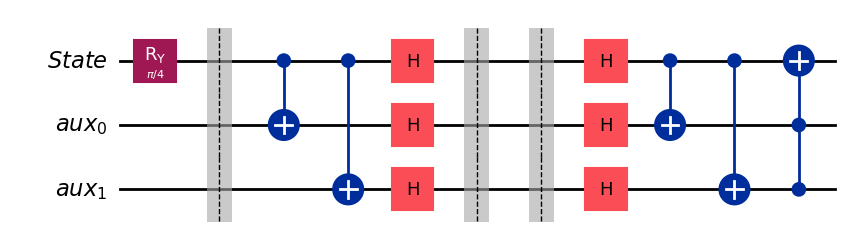

##############################
Case: Phase-flip noise on one qubit
##############################
Final state:


<IPython.core.display.Latex object>

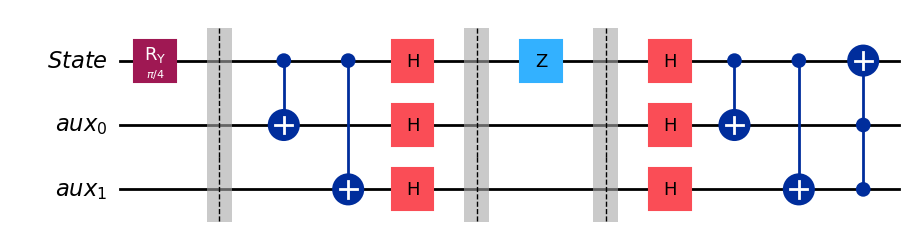

##############################
Case: Phase-flip noise on two qubits
##############################
Final state:


<IPython.core.display.Latex object>

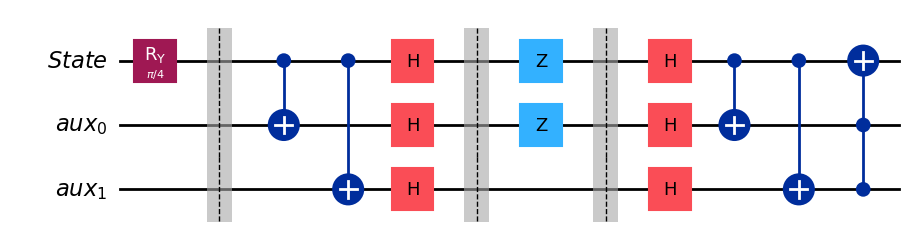

##############################
Case: Phase-flip noise on all three qubits
##############################
Final state:


<IPython.core.display.Latex object>

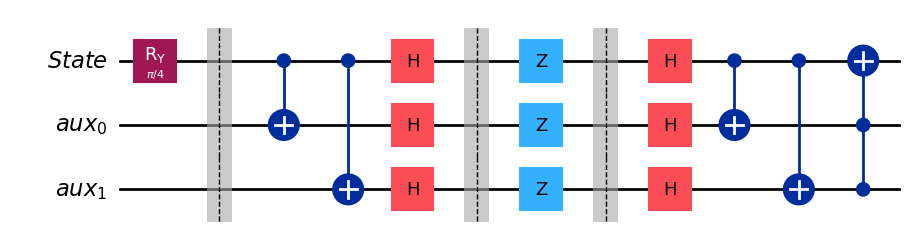

In [82]:
noise_cases = [
    [],  
    [0],   
    [0, 1],   
    [0, 1, 2],     
]

cases_description = [
    "No phase-flip noise",
    "Phase-flip noise on one qubit",
    "Phase-flip noise on two qubits",
    "Phase-flip noise on all three qubits"
]


# Initial state preparation
initial_state = QuantumCircuit(1)
initial_state.ry(np.pi / 4, 0)
sv_init = Statevector.from_instruction(initial_state)
print("Initial state:")
display(sv_init.draw("latex"))

for i in range(4):
    qc = phase_flip_circuit(initial_state, noise_cases[i])
    sv = Statevector.from_instruction(qc)
    print(30 * "#")
    print("Case:", cases_description[i])
    print(30 * "#")
    print("Final state:")
    display(sv.draw("latex"))
    display(qc.draw("mpl"))

The results are analogous to the bit-flip case. The phase-flip code correctly preserves the logical state when there is no error or only one phase-flip error, but it cannot correct cases where two or more qubits are affected.

# Shor code

Combining these two circuit we can build the Shor code: a quantum circuit capable of detecting both bit-flips and phase flips. The idea is quite intuitive: first, the logical qubit is protected against phase-flip errors by encoding it into three blocks. Then, each of these blocks is itself encoded using a three-qubit bit-flip code. In this sense, the code behaves like three phase-flip protected components, where each component is also protected against bit-flip errors.

This works because bit-flip and phase-flip errors can be treated separately. A general single-qubit error can be decomposed in terms of Pauli errors, mainly $X$, $Z$, and $Y$, where $Y$ is equivalent to a combination of $X$ and $Z$ up to a global phase. Although $X$ and $Z$ do not commute, since $ZX = -XZ$, this minus sign is only a global phase in the error operation and does not affect the correction procedure.

The Shor code is a $[[9,1,3]]$ quantum error correction code. Since its distance is $d=3$, it can correct any arbitrary single-qubit error and detect up to two arbitrary qubit errors. However, if two errors occur, the code cannot always identify and correct them reliably.

In [85]:
def phase_flip_circuit(initial_state: QuantumCircuit, bit_flip_idx: list[int], phase_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds the Shor code circuit for a 1-qubit initial state, applying X anb Z noise according to bit_flip_idx and phase_flip_idx.
    """
    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    
    qc = QuantumCircuit(9)

    # Prepare the initial state
    qc.compose(initial_state, qubits=[0], inplace=True)
    qc.barrier()

    # Encoding
    qc.cx(0, 3)
    qc.cx(0, 6)
    for qubit in [0, 3, 6]:
        qc.h(qubit)
        qc.cx(qubit, qubit + 1)
        qc.cx(qubit, qubit + 2)
    qc.barrier()

    # Noise
    if len(phase_flip_idx) > 0:
        qc.z(phase_flip_idx)
    if len(bit_flip_idx) > 0:
        qc.x(bit_flip_idx)
    qc.barrier()

    # Error correction
    for qubit in [0, 3, 6]:
        qc.cx(qubit, qubit + 1)
        qc.cx(qubit, qubit + 2)
        qc.ccx(qubit + 1, qubit + 2, qubit)
        qc.h(qubit)
    qc.cx(0, 3)
    qc.cx(0, 6)
    qc.ccx(6, 3, 0)

    return qc

Initial state:


<IPython.core.display.Latex object>

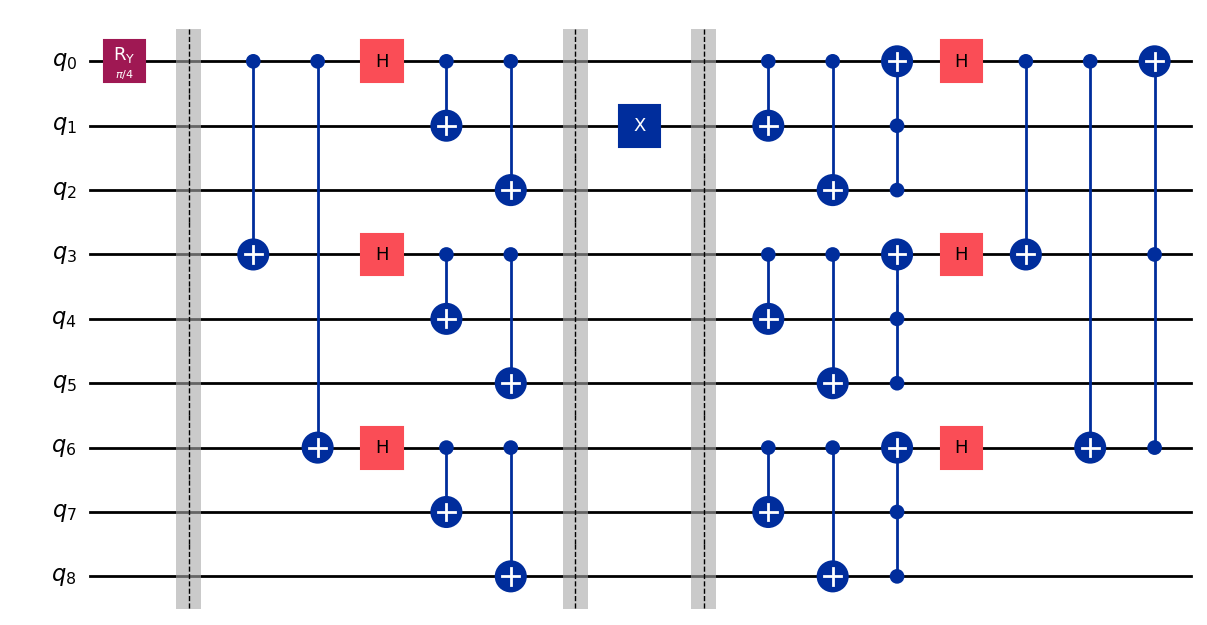

In [86]:
# Initial state preparation
initial_state = QuantumCircuit(1)
initial_state.ry(np.pi / 4, 0)
sv_init = Statevector.from_instruction(initial_state)
print("Initial state:")
display(sv_init.draw("latex"))

qc = phase_flip_circuit(initial_state, [1], [])
qc.draw("mpl")

# Steane code